# MAIN FUNCTIONS

In [ ]:
import fastf1
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

# use the data stored locally
fastf1.Cache.enable_cache('../data/raw')

def load_and_clean_race(year, race_name):

    # load the race
    session = fastf1.get_session(year, race_name, 'R')
    session.load()

    laps_og = session.laps
    laps = laps_og.copy()

    # add Race_ID to track which event these laps belong to when scaled
    laps['Race_ID'] = f"{year}_{race_name}"

    # !!!!!!!!!!!!!!!!!!!!!!!!Save a copy of the raw laps for report
    raw_laps_export = laps.copy()

    # DYNAMIC FUEL BURN ######################################################
    # calculate on all laps before eliminating safety car/inter laps!!!!!!!!!!!!

    # get slow laps = safety car, VSC, pit in/out
    is_slow_lap = (
        laps['TrackStatus'].str.contains('4|6', na=False, regex=True) | 
        laps['PitInTime'].notnull() | 
        laps['PitOutTime'].notnull()
    )

    # 0.4kg for slow laps, 1.7kg for normal racing laps
    laps['Dynamic_Burn'] = np.where(is_slow_lap, 0.4, 1.7)
    laps['Cumulative_Fuel_Burn'] = laps.groupby('Driver')['Dynamic_Burn'].cumsum()
    # calc dynamic mass
    laps['Estimated_Fuel_Mass'] = 105.0 - laps['Cumulative_Fuel_Burn']

    # !!!!!!!!!!!!!!!!!!!!!!Capture wet laps before dropping them 
    wet_laps_export = laps[~laps['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])].copy()

    # keep only DRY compounds = drop any WET compounds
    laps = laps[laps['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]

    # drop incomplete/inaccurate laps - safety car laps, pit laps
    clean_laps = laps[laps['IsAccurate'] == True]
    clean_laps = clean_laps[clean_laps['PitInTime'].isnull() & clean_laps['PitOutTime'].isnull()]
    clean_laps = clean_laps[~clean_laps['TrackStatus'].str.contains('4|6', na=False, regex=True)]

    # create Stint_ID - Cross-Validation Grouping Key
    # a 'STINT' is a continuous run on one set of tires
    # combine RaceID + Driver's 3-letter code +  their integer Stint number
    # clean_laps['Stint_ID'] = clean_laps['Driver'] + "_Stint_" + clean_laps['Stint'].astype(int).astype(str)
    clean_laps['Stint_ID'] = clean_laps['Race_ID'] + "_" + clean_laps['Driver'] + "_Stint_" + clean_laps['Stint'].astype(int).astype(str)

    # define the target variable
    clean_laps['Target_Compound'] = clean_laps['Compound']

    # convert LapTime from ns to s
    clean_laps['LapTime_Sec'] = clean_laps['LapTime'].dt.total_seconds()

    # get race progression feature
    total_laps = session.total_laps 
    clean_laps['Race_Progression'] = clean_laps['LapNumber'] / total_laps

    print(f"Original laps: {len(laps)}")

    # return clean_laps, session
    return clean_laps, session, raw_laps_export, wet_laps_export


def calculate_baseline_pace(clean_laps):
    top3_avg = (
        clean_laps.groupby('LapNumber')['LapTime_Sec']
        .nsmallest(3)                # top 3 fastest times
        .groupby('LapNumber')          # regroup by LapNumber
        .mean()                       # average those 3 times
        .reset_index()
    )
    top3_avg.rename(columns={'LapTime_Sec': 'Top3_Avg_Sec'}, inplace=True)

    # sort by LapNumber to ensure chronological order
    top3_avg = top3_avg.sort_values('LapNumber')

    # Exponential Moving Average (EMA) to smooth out spikes
    # span=5 -> EMA gives the most weight to the last 5 laps 
    top3_avg['Field_Best_Lap_Sec'] = top3_avg['Top3_Avg_Sec'].ewm(span=5, adjust=False).mean()

    smoothed_baseline = top3_avg[['LapNumber', 'Field_Best_Lap_Sec']]
    clean_laps = clean_laps.merge(smoothed_baseline, on='LapNumber', how='left')

    # calc DELTA: how much slower was this driver compared to the smoothed track evolution curve
    clean_laps['Delta_to_Field_Best'] = clean_laps['LapTime_Sec'] - clean_laps['Field_Best_Lap_Sec']

    print(f"Clean laps remaining: {len(clean_laps)}")
    # print(clean_laps.head())

    return clean_laps

#################################################################### TELEMTRY AND FEATURE ENGINEERING ######################################################################

def extract_telemetry_and_physics(clean_laps, session):
    print("Extracting bulk telemetry per driver...")
    telemetry_list = []

    for driver in clean_laps['Driver'].unique():
        driver_laps = session.laps.pick_drivers(driver)
        
        try:
            driver_tel = driver_laps.get_telemetry()
        except Exception as e:
            print(f"Error fetching telemetry for {driver}: {e}")
            continue

        driver_tel = driver_tel.sort_values('SessionTime')
        lap_starts = driver_laps[['LapNumber', 'LapStartTime']].dropna().sort_values('LapStartTime')
        
        merged_tel = pd.merge_asof(
            driver_tel,
            lap_starts,
            left_on='SessionTime',
            right_on='LapStartTime',
            direction='backward'
        )
        
        merged_tel['Driver'] = driver
        
        valid_laps = clean_laps[clean_laps['Driver'] == driver]['LapNumber'].unique()
        merged_tel = merged_tel[merged_tel['LapNumber'].isin(valid_laps)]
        
        telemetry_list.append(merged_tel)

    if not telemetry_list:
        print("Failed to fetch any telemetry. Returning original laps.")
        return clean_laps

    # combine all drivers into one dataframe
    bulk_tel = pd.concat(telemetry_list, ignore_index=True)

    speed_ms = (bulk_tel['Speed'] / 3.6).replace(0, 0.001)
    bulk_tel['Time_Gap_Ahead'] = bulk_tel['DistanceToDriverAhead'] / speed_ms
    bulk_tel['In_Dirty_Air'] = (bulk_tel['Time_Gap_Ahead'] > 0) & (bulk_tel['Time_Gap_Ahead'] <= 2.5)
    bulk_tel['Dirty_Air_Cornering'] = bulk_tel['In_Dirty_Air'] & (bulk_tel['Speed'] < 250) & (bulk_tel['Throttle'] >= 80)
    
    bulk_tel['Full_Throttle'] = bulk_tel['Throttle'] >= 99
    bulk_tel['Brake_Active'] = (bulk_tel['Brake'] > 0).astype(int)

    # BRAKE EVENTS within each lap group
    bulk_tel['Brake_Transition'] = bulk_tel.groupby(['Driver', 'LapNumber'])['Brake_Active'].diff()
    bulk_tel['Brake_Event'] = (bulk_tel['Brake_Transition'] == 1).astype(int)

    grouped = bulk_tel.groupby(['Driver', 'LapNumber'])
    
    tel_features = grouped.agg(
        Avg_Speed=('Speed', 'mean'),
        Std_Dev_Speed=('Speed', 'std'),
        Min_Speed=('Speed', 'min'),
        Corner_Speed_10th=('Speed', lambda x: x.quantile(0.10)),
        Avg_RPM=('RPM', 'mean'),
        Avg_Throttle=('Throttle', 'mean'),
        Percent_Full_Throttle=('Full_Throttle', 'mean'),
        Percent_Dirty_Air=('In_Dirty_Air', 'mean'),
        Dirty_Air_Cornering=('Dirty_Air_Cornering', 'mean'),
        Brake_Events=('Brake_Event', 'sum') 
    ).reset_index()
    
    clean_laps = pd.merge(clean_laps, tel_features, on=['Driver', 'LapNumber'], how='inner')

    # MECHANICAL GRIP & INERTIA #################################################
    clean_laps['Cornering_Energy'] = clean_laps['Estimated_Fuel_Mass'] * (clean_laps['Corner_Speed_10th'] ** 2)
    clean_laps['Car_Momentum'] = clean_laps['Estimated_Fuel_Mass'] * clean_laps['Avg_Speed']

    # DEGRADATION DERIVATIVE ##################################################
    clean_laps['Degradation_Slope'] = (
        clean_laps.groupby('Stint_ID')['Delta_to_Field_Best']
        .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    )

    # WEATHER DATA ############################################################
    weather_data = session.weather_data.sort_values(by='Time')
    clean_laps = clean_laps.sort_values(by='LapStartTime')
    weather_subset = weather_data[['Time', 'TrackTemp', 'AirTemp']].rename(columns={'Time': 'Weather_Time'})

    clean_laps = pd.merge_asof(
        clean_laps, 
        weather_subset,
        left_on='LapStartTime', 
        right_on='Weather_Time', 
        direction='backward'
    )
    clean_laps.drop(columns=['Weather_Time'], inplace=True)

    features_to_normalize = [
        'Avg_Speed', 'Std_Dev_Speed', 'Min_Speed', 'Corner_Speed_10th', 
        'Avg_RPM', 'Avg_Throttle', 'Percent_Full_Throttle', 'Brake_Events', 
        'Percent_Dirty_Air', 'Dirty_Air_Cornering', 'Cornering_Energy', 
        'Car_Momentum', 'TrackTemp', 'AirTemp'
    ]
    
    for col in features_to_normalize:
        if col in clean_laps.columns:
            col_mean = clean_laps[col].mean()
            col_std = clean_laps[col].std()
            
            if col_std == 0 or pd.isna(col_std):
                clean_laps[col] = 0.0
            else:
                # Z = (x - mean) / std
                clean_laps[col] = (clean_laps[col] - col_mean) / col_std

    print(f"Database final shape: {clean_laps.shape}")
    return clean_laps


def process_race(year, race_name, features):
    print(f"Processing {year} {race_name}...")

    clean_laps, session, raw_laps_export, wet_laps_export = load_and_clean_race(year, race_name)
    clean_laps = calculate_baseline_pace(clean_laps)
    final_df = extract_telemetry_and_physics(clean_laps, session)

    ################################################################################################################################
    # ONLY WHEN MORE RACES ARE AVAILABLE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    # convert the boolean 'FreshTyre' column to integers (1 = Fresh, 0 = Scrubbed)
    # XGBoost requires numeric features, so we map True/False to 1/0
    # clean_laps_fresh['FreshTyre'] = clean_laps_fresh['FreshTyre'].astype(int)
    ################################################################################################################################

    metadata = ['Target_Compound', 'Stint_ID', 'Race_ID']

    # !!!!!!!!!!!!!!!! capture pre-dropna state
    pre_dropna_df = final_df[metadata + features].copy()
    
    model_df = final_df[metadata + features].copy().dropna()

    print(f"final modeling database shape: {model_df.shape}")
    # print(model_df.columns)
    
    return model_df, raw_laps_export, wet_laps_export, pre_dropna_df

# PROCESS RACES

In [ ]:
races_to_process = [
    'Australia', 
    'China', 
    'Japan', 
    'Bahrain', 
    'Saudi Arabia', 
    'Miami', 
    'Emilia Romagna', 
    'Monaco', 
    'Spain', 
    'Canada', 
    'Austria', 
    'Great Britain', 
    'Belgium', 
    'Hungary', 
    'Netherlands', 
    'Italy', 
    'Azerbaijan', 
    'Singapore', 
    'United States', # austin
    'Mexico', 
    'São Paulo',     # brazil
    'Las Vegas', 
    'Qatar', 
    'Abu Dhabi'
]

year = 2025

features = [
            'Delta_to_Field_Best',
            'Avg_Speed',
            'Std_Dev_Speed',
            'Min_Speed',
            'Corner_Speed_10th',
            'Avg_RPM', 
            'Avg_Throttle',
            'Percent_Full_Throttle',
            'Brake_Events', 
            'Percent_Dirty_Air', 
            'Dirty_Air_Cornering',
            'Cornering_Energy', 
            'Car_Momentum',
            'Degradation_Slope', 
            'TrackTemp', 
            'TyreLife',
            'Race_Progression'
    ]

all_races_df = []
all_raw_laps = []
all_wet_laps = []
all_pre_dropna = []

for race in races_to_process:
    df, raw_df, wet_df, pre_dropna_df = process_race(year, race, features)
    all_races_df.append(df)
    all_raw_laps.append(raw_df)
    all_wet_laps.append(wet_df)
    all_pre_dropna.append(pre_dropna_df)

# concatenate into master DataFrames
master_df = pd.concat(all_races_df, ignore_index=True)
master_raw_df = pd.concat(all_raw_laps, ignore_index=True)
master_wet_df = pd.concat(all_wet_laps, ignore_index=True)
master_pre_dropna_df = pd.concat(all_pre_dropna, ignore_index=True)

print(f"1. Total Raw Laps recorded across all races: {len(master_raw_df)}")
print(f"2. Laps removed due to Wet/Inter compounds:  {len(master_wet_df)}")

# eliminated SC/VSC/In/Out laps 
slow_laps_dropped = len(master_raw_df) - len(master_wet_df) - len(master_pre_dropna_df)
print(f"3. Laps removed (Safety Car, Pits, Inaccurate): {slow_laps_dropped}")

print(f"4. Laps entering telemetry extraction:       {len(master_pre_dropna_df)}")

nan_dropped = len(master_pre_dropna_df) - len(master_df)
print(f"5. Laps dropped due to Missing/NaN Telemetry: {nan_dropped}")
print(f"6. FINAL CLEAN DATASET SIZE:                 {len(master_df)}")

print("Final Dataset Info:")
print(master_df.info())

Processing 2025 Australia...


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

Original laps: 177
Clean laps remaining: 50
Extracting bulk telemetry per driver...


core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Vectorizing calculations over 33524 telemetry data points...
Database final shape: (50, 56)
final modeling database shape: (48, 20)
Processing 2025 China...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '31', '12', '23', '87', '18', '55', '6', '30', '7', '5', '27', '22', '14', '16', '44', '10']


Original laps: 1065
Clean laps remaining: 995
Extracting bulk telemetry per driver...
Vectorizing calculations over 728270 telemetry data points...


core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (995, 56)
final modeling database shape: (995, 20)
Processing 2025 Japan...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '12', '44', '6', '23', '87', '14', '22', '10', '55', '7', '27', '30', '31', '5', '18']


Original laps: 1059
Clean laps remaining: 997
Extracting bulk telemetry per driver...
Vectorizing calculations over 698788 telemetry data points...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (997, 56)
final modeling database shape: (997, 20)
Processing 2025 Bahrain...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


Original laps: 1128
Clean laps remaining: 952
Extracting bulk telemetry per driver...
Vectorizing calculations over 705800 telemetry data points...


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (952, 56)
final modeling database shape: (952, 20)
Processing 2025 Saudi Arabia...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '1', '16', '4', '63', '12', '44', '55', '23', '6', '14', '30', '87', '31', '27', '18', '7', '5', '22', '10']


Original laps: 898
Clean laps remaining: 810
Extracting bulk telemetry per driver...
Vectorizing calculations over 576630 telemetry data points...


core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (810, 56)
final modeling database shape: (810, 20)
Processing 2025 Miami...


core        WARNING 	Fixed incorrect tyre stint information for driver '6'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core        WARNING 	Fixed incorrect tyre stint information for driver '18'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 81 completed the race distance 00:00.036000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '23', '12', '16', '44', '55', '22', '6', '31', '10', '27', '14', '18', '30', '5', '87', '7']


Original laps: 559
Clean laps remaining: 479
Extracting bulk telemetry per driver...
Vectorizing calculations over 330632 telemetry data points...


core           INFO 	Loading data for Emilia Romagna Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (479, 56)
final modeling database shape: (479, 20)
Processing 2025 Emilia Romagna...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '44', '23', '16', '63', '55', '6', '22', '14', '27', '10', '30', '18', '43', '87', '5', '12', '31']


Original laps: 1207
Clean laps remaining: 956
Extracting bulk telemetry per driver...
Vectorizing calculations over 584246 telemetry data points...


core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (956, 56)
final modeling database shape: (956, 20)
Processing 2025 Monaco...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '1', '44', '6', '31', '30', '23', '55', '63', '87', '43', '5', '18', '27', '22', '12', '14', '10']


Original laps: 1425
Clean laps remaining: 1271
Extracting bulk telemetry per driver...
Vectorizing calculations over 737217 telemetry data points...


core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (1271, 56)
final modeling database shape: (1271, 20)
Processing 2025 Spain...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 19 drivers: ['81', '4', '16', '63', '27', '44', '6', '10', '14', '1', '30', '5', '22', '55', '43', '31', '87', '12', '23']


Original laps: 1203
Clean laps remaining: 990
Extracting bulk telemetry per driver...
Vectorizing calculations over 604037 telemetry data points...


core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (990, 56)
final modeling database shape: (990, 20)
Processing 2025 Canada...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['63', '1', '12', '81', '16', '44', '14', '27', '31', '55', '87', '22', '43', '5', '10', '6', '18', '4', '30', '23']


Original laps: 1349
Clean laps remaining: 1197
Extracting bulk telemetry per driver...
Vectorizing calculations over 688385 telemetry data points...


core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (1197, 56)
final modeling database shape: (1197, 20)
Processing 2025 Austria...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '16', '44', '63', '30', '14', '5', '27', '31', '87', '6', '10', '18', '43', '22', '23', '1', '12', '55']


Original laps: 1127
Clean laps remaining: 1010
Extracting bulk telemetry per driver...
Vectorizing calculations over 540754 telemetry data points...


events      WARNING 	Correcting user input 'Great Britain' to 'Austrian Grand Prix'
core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (1010, 56)
final modeling database shape: (1010, 20)
Processing 2025 Great Britain...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '16', '44', '63', '30', '14', '5', '27', '31', '87', '6', '10', '18', '43', '22', '23', '1', '12', '55']


Original laps: 1127
Clean laps remaining: 1010
Extracting bulk telemetry per driver...
Vectorizing calculations over 540754 telemetry data points...


core           INFO 	Loading data for Belgian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '81'
core        WARNING 	Fixed incorrect tyre stint information for driver '4'
core        WARNING 	Fixed incorrect tyre stint information for driver '16'


Database final shape: (1010, 56)
final modeling database shape: (1010, 20)
Processing 2025 Belgium...


core        WARNING 	Fixed incorrect tyre stint information for driver '1'
core        WARNING 	Fixed incorrect tyre stint information for driver '63'
core        WARNING 	Fixed incorrect tyre stint information for driver '23'
core        WARNING 	Fixed incorrect tyre stint information for driver '44'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Fixed incorrect tyre stint information for driver '10'
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '27'
core        WARNING 	Fixed incorrect tyre stint information for driver '22'
core        WARNING 	Fixed incorrect tyre stint information for driver '18'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core        WARNING 	Fixed incorrect tyre stint information for driver '12'
core        WA

Original laps: 583
Clean laps remaining: 554
Extracting bulk telemetry per driver...
Vectorizing calculations over 450453 telemetry data points...


core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (554, 56)
final modeling database shape: (537, 20)
Processing 2025 Hungary...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '63', '16', '14', '5', '18', '30', '1', '12', '6', '44', '27', '55', '23', '31', '22', '43', '10', '87']


Original laps: 1368
Clean laps remaining: 1289
Extracting bulk telemetry per driver...
Vectorizing calculations over 798972 telemetry data points...


core           INFO 	Loading data for Dutch Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (1289, 56)
final modeling database shape: (1289, 20)
Processing 2025 Netherlands...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '1', '6', '63', '23', '87', '18', '14', '22', '31', '43', '30', '55', '27', '5', '12', '10', '4', '16', '44']


Original laps: 1364
Clean laps remaining: 1041
Extracting bulk telemetry per driver...
Vectorizing calculations over 589919 telemetry data points...
Database final shape: (1041, 56)
final modeling database shape: (1041, 20)
Processing 2025 Italy...


events      WARNING 	Correcting user input 'Italy' to 'Italian Grand Prix'
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '44', '23', '5', '12', '6', '55', '87', '22', '30', '31', '10', '43', '18',

Original laps: 975
Clean laps remaining: 916
Extracting bulk telemetry per driver...
Vectorizing calculations over 574931 telemetry data points...


core           INFO 	Loading data for Azerbaijan Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (916, 56)
final modeling database shape: (916, 20)
Processing 2025 Azerbaijan...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 00:00.015000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '63', '55', '12', '30', '22', '4', '44', '16', '6', '5', '87', '23', '31', '14', '27', '18', '10', '43', '81']


Original laps: 968
Clean laps remaining: 855
Extracting bulk telemetry per driver...
Vectorizing calculations over 678426 telemetry data points...


core           INFO 	Loading data for Singapore Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (855, 56)
final modeling database shape: (855, 20)
Processing 2025 Singapore...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['63', '1', '4', '81', '12', '16', '14', '44', '87', '55', '6', '22', '18', '23', '30', '43', '5', '31', '10', '27']


Original laps: 1229
Clean laps remaining: 1163
Extracting bulk telemetry per driver...
Vectorizing calculations over 858958 telemetry data points...


events      WARNING 	Correcting user input 'United States' to 'United States Grand Prix'
core           INFO 	Loading data for United States Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (1163, 56)
final modeling database shape: (1163, 20)
Processing 2025 United States...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '16', '44', '81', '63', '22', '27', '87', '14', '30', '18', '12', '23', '31', '6', '43', '5', '10', '55']


Original laps: 1067
Clean laps remaining: 963
Extracting bulk telemetry per driver...
Vectorizing calculations over 725338 telemetry data points...


core           INFO 	Loading data for Mexico City Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (963, 56)
final modeling database shape: (963, 20)
Processing 2025 Mexico...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '1', '87', '81', '12', '63', '44', '31', '5', '22', '23', '6', '18', '10', '43', '55', '14', '27', '30']


Original laps: 1263
Clean laps remaining: 1153
Extracting bulk telemetry per driver...
Vectorizing calculations over 714365 telemetry data points...


core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Database final shape: (1153, 56)
final modeling database shape: (1153, 20)
Processing 2025 São Paulo...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.010000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '12', '1', '63', '81', '87', '30', '6', '27', '10', '23', '31', '55', '14', '43', '18', '22', '44', '16', '5']


Original laps: 1251
Clean laps remaining: 1049
Extracting bulk telemetry per driver...
Vectorizing calculations over 591400 telemetry data points...


core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '63'


Database final shape: (1049, 56)
final modeling database shape: (1049, 20)
Processing 2025 Las Vegas...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '63', '12', '16', '55', '6', '27', '44', '31', '87', '14', '22', '10', '30', '43', '23', '5', '18', '4', '81']


Original laps: 886
Clean laps remaining: 760
Extracting bulk telemetry per driver...
Vectorizing calculations over 554252 telemetry data points...


events      WARNING 	Correcting user input 'Qatar' to 'Qatar Grand Prix'
core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (760, 56)
final modeling database shape: (760, 20)
Processing 2025 Qatar...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']


Original laps: 1067
Clean laps remaining: 922
Extracting bulk telemetry per driver...
Vectorizing calculations over 594028 telemetry data points...


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (922, 56)
final modeling database shape: (922, 20)
Processing 2025 Abu Dhabi...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


Original laps: 1156
Clean laps remaining: 1082
Extracting bulk telemetry per driver...
Vectorizing calculations over 726182 telemetry data points...
Database final shape: (1082, 56)
final modeling database shape: (1082, 20)

🏁 DATA PROCESSING PIPELINE SUMMARY 🏁
1. Total Raw Laps recorded across all races: 26993
2. Laps removed due to Wet/Inter compounds:  1492
3. Laps removed (Safety Car, Pits, Inaccurate): 3037
4. Laps entering telemetry extraction:       22464
5. Laps dropped due to Missing/NaN Telemetry: 19
6. FINAL CLEAN DATASET SIZE:                 22445

Final Dataset Info:
<class 'fastf1.core.Laps'>
RangeIndex: 22445 entries, 0 to 22444
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Target_Compound        22445 non-null  object 
 1   Stint_ID               22445 non-null  object 
 2   Race_ID                22445 non-null  object 
 3   Delta_to_Field_Best    22445 non-null  float64
 4

# PLOT LAPS BY TYRE COMPOUND

C:\Users\c\AppData\Local\Temp\ipykernel_19032\3703855997.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=compound_counts.index, y=compound_counts.values, palette=colors, edgecolor='black')


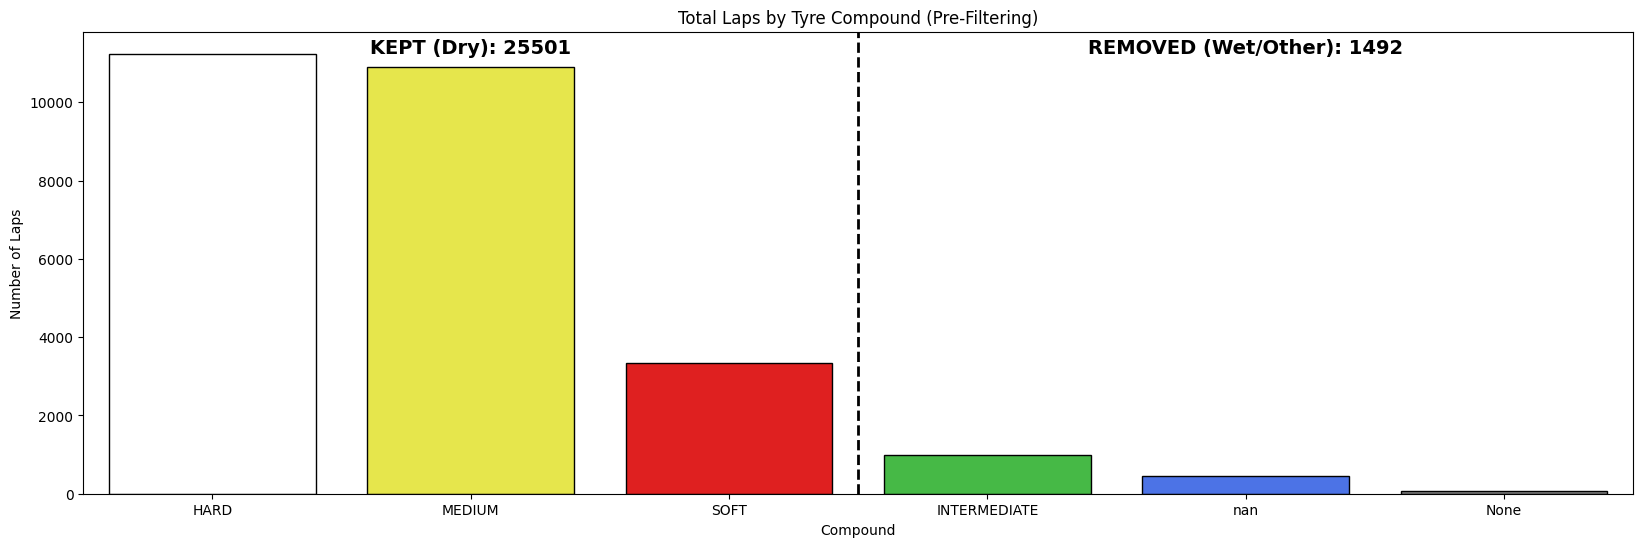

Total Tyres/Laps starting: 26993
Total Tyres/Laps removed: 1492


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

compound_counts = master_raw_df['Compound'].value_counts()

dry_compounds = ['SOFT', 'MEDIUM', 'HARD']
# ORDER: Soft, Med, Hard, Inter, Wet, Unknown
colors = ["#FFFFFF", '#FFFF33', "#FF0000", '#33CC33', '#3366FF', '#808080'] 

plt.figure(figsize=(20, 6))
ax = sns.barplot(x=compound_counts.index, y=compound_counts.values, palette=colors, edgecolor='black')

plt.axvline(x=2.5, color='black', linestyle='--', linewidth=2)
plt.text(1, max(compound_counts)*1.0, 'KEPT (Dry): 25501', fontsize=14, fontweight='bold', ha='center')
plt.text(4, max(compound_counts)*1.0, 'REMOVED (Wet/Other): 1492', fontsize=14, fontweight='bold', ha='center')

plt.title("Total Laps by Tyre Compound (Pre-Filtering)")
plt.ylabel("Number of Laps")
plt.xlabel("Compound")
plt.show()

print(f"Total Tyres/Laps starting: {len(master_raw_df)}")
print(f"Total Tyres/Laps removed: {len(master_wet_df)}")

# PLOT LAPS FILTERING

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name = "Data Cleaning", orientation = "v",
    measure = ["absolute", "relative", "relative", "relative", "total"],
    x = ["Raw Laps", "Wet/Inter Tires", "SC/Pit Laps", "Missing Telemetry", "Final Clean Laps"],
    textposition = "outside",
    y = [26993, -1492, -3037, -19, 0],
    text = ["26,993", "-1,492", "-3,037", "-19", "22,445"],
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
))

fig.update_layout(
    title = "Data Processing Pipeline: Laps Removed vs. Remaining",
    showlegend = False,
    waterfallgap = 0.4
)

fig.show()

# PLOT DISTRIBUTION OF STINT LENGHTS BY COMPOUND

C:\Users\c\AppData\Local\Temp\ipykernel_19032\895946893.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


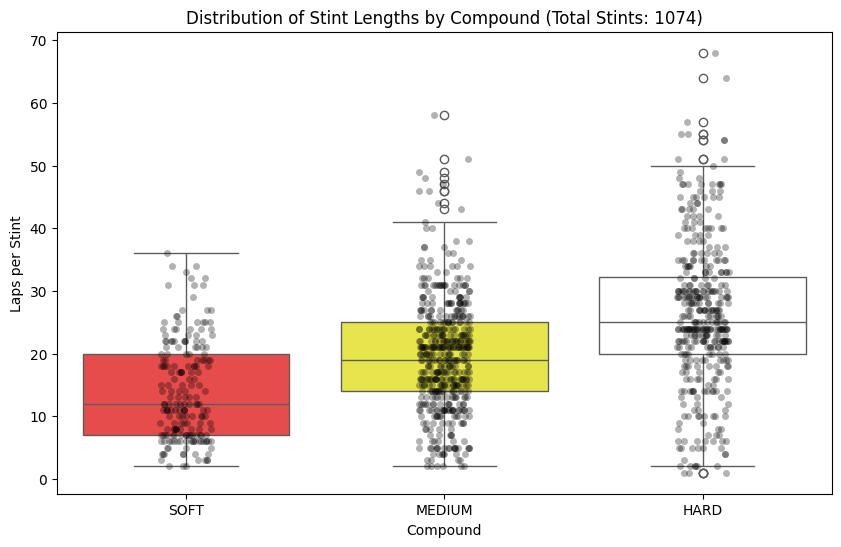

🏎️ EXTREME HARD TIRE STINTS (>60 Laps):
               Stint_ID Target_Compound  Stint_Length
2025_Monaco_TSU_Stint_2            HARD            68
2025_Monaco_ANT_Stint_1            HARD            64


🟡 EXTREME MEDIUM TIRE STINTS (>50 Laps):
                  Stint_ID Target_Compound  Stint_Length
   2025_Monaco_BEA_Stint_3          MEDIUM            58
2025_São Paulo_LAW_Stint_2          MEDIUM            51


🔴 EXTREME SOFT TIRE STINTS (>30 Laps):
                  Stint_ID Target_Compound  Stint_Length
2025_Singapore_STR_Stint_1            SOFT            36
2025_São Paulo_HUL_Stint_2            SOFT            34
   2025_Mexico_GAS_Stint_2            SOFT            34
   2025_Mexico_HAD_Stint_2            SOFT            33
   2025_Mexico_TSU_Stint_2            SOFT            32
   2025_Mexico_NOR_Stint_1            SOFT            32
   2025_Mexico_BOR_Stint_2            SOFT            31
   2025_Monaco_HUL_Stint_3            SOFT            31
   2025_Mexico_VER_Stint_2    

In [ ]:
stint_lengths = master_df.groupby(['Stint_ID', 'Target_Compound']).size().reset_index(name='Stint_Length')

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=stint_lengths, 
    x='Target_Compound', 
    y='Stint_Length', 
    order=['SOFT', 'MEDIUM', 'HARD'],
    palette={'SOFT': '#FF3333', 'MEDIUM': '#FFFF33', 'HARD': '#FFFFFF'}
)

sns.stripplot(
    data=stint_lengths, 
    x='Target_Compound', 
    y='Stint_Length', 
    order=['SOFT', 'MEDIUM', 'HARD'],
    color='black', 
    alpha=0.3,
    jitter=True
)

plt.title(f"Distribution of Stint Lengths by Compound (Total Stints: {len(stint_lengths)})")
plt.ylabel("Laps per Stint")
plt.xlabel("Compound")
plt.show()

hard_outliers = stint_lengths[
    (stint_lengths['Target_Compound'] == 'HARD') & 
    (stint_lengths['Stint_Length'] >= 60)
].sort_values('Stint_Length', ascending=False)

medium_outliers = stint_lengths[
    (stint_lengths['Target_Compound'] == 'MEDIUM') & 
    (stint_lengths['Stint_Length'] >= 50)
].sort_values('Stint_Length', ascending=False)

soft_outliers = stint_lengths[
    (stint_lengths['Target_Compound'] == 'SOFT') & 
    (stint_lengths['Stint_Length'] >= 30)
].sort_values('Stint_Length', ascending=False)

print("EXTREME HARD TIRE STINTS (>60 Laps):")
print(hard_outliers.to_string(index=False))
print("\n")

print("EXTREME MEDIUM TIRE STINTS (>50 Laps):")
print(medium_outliers.to_string(index=False))
print("\n")

print("EXTREME SOFT TIRE STINTS (>30 Laps):")
print(soft_outliers.to_string(index=False))

## SAVE/IMPORT CLEAN/FILTERED DATABASE

In [ ]:
############################################ DATABASE MODELING VERIFICATION #################################################
import os

os.makedirs('../data/cleaned', exist_ok=True)
master_df.to_csv('../data/cleaned/maser_df.csv', index=False)


In [ ]:
import pandas as pd

master_df = pd.read_csv('../data/cleaned/maser_df.csv')

print(df.head())

print(df.info())

# SPLIT DATASET

In [ ]:
########################################################### SPLIT DATASET ##############################################
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit

color_mapping = {'HARD': 0, 'MEDIUM': 1, 'SOFT': 2}
master_df['Target_Encoded'] = master_df['Target_Compound'].map(color_mapping)

master_df.dropna(subset=['Target_Encoded'], inplace=True)
master_df['Target_Encoded'] = master_df['Target_Encoded'].astype(int)
print(master_df['Target_Encoded'].value_counts())

master_df = master_df.reset_index(drop=True)

# LO-RO METHOD
X = master_df[features]
y = master_df['Target_Encoded']
groups_race = master_df['Race_ID'] 

print(f"\nTotal dataset size: {X.shape[0]} laps across {groups_race.nunique()} races.")


Target_Encoded
0    10139
1     9558
2     2748
Name: count, dtype: int64

Total dataset size: 22445 laps across 24 races.
g


# TRAIN MODEL

In [ ]:
############################################################### MODEL TRAINING ##############################################################
from sklearn.model_selection import StratifiedGroupKFold, LeaveOneGroupOut
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report, f1_score
import xgboost as xgb
import catboost as cb
import lightgbm as gbm
import optuna
import numpy as np


# define the Optuna obj function for XGBOOST
def obj_xgboost(trial):

    param = {
        'objective': 'multi:softmax',
        'num_class': 3,
        'tree_method': 'hist',
        'random_state': 42,
        'max_depth': trial.suggest_int('max_depth', 3, 7), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True)
    }
    
    logo = LeaveOneGroupOut()
    f1_scores = []
    
    for cv_train_idx, cv_val_idx in logo.split(X, y, groups=groups_race):
        X_cv_train, X_cv_val = X.iloc[cv_train_idx], X.iloc[cv_val_idx]
        y_cv_train, y_cv_val = y.iloc[cv_train_idx], y.iloc[cv_val_idx]

        classes = np.unique(y_cv_train)
        weights = compute_class_weight('balanced', classes=classes, y=y_cv_train)
        weight_dict = dict(zip(classes, weights))

        # boost SOFT tire weight
        if 2 in weight_dict:
            weight_dict[2] = weight_dict[2] * 2.0 

        # map weights to individual samples
        sample_weights = y_cv_train.map(weight_dict)
        
        # initialize and train XGBoost classifier model
        model = xgb.XGBClassifier(**param)
        model.fit(
            X_cv_train, y_cv_train,
            sample_weight=sample_weights,
            verbose=False
        )
        
        # predict and evaluate using Macro F1-Score
        preds = model.predict(X_cv_val)
        f1_scores.append(f1_score(y_cv_val, preds, average='macro'))

    return np.mean(f1_scores)

# run the OPTUNA study
study = optuna.create_study(direction='maximize')
study.optimize(obj_xgboost, n_trials=150) 

print(f"Best Macro F1-Score: {study.best_trial.value:.4f}")
print(f"Best Parameters: {study.best_trial.params}")

# inject static parameters back into final model
best_params = study.best_trial.params
best_params.update({
    'objective': 'multi:softmax',
    'num_class': 3,
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs':-1,
})


print("\nEvaluating final model using Leave-One-Race-Out...")
logo = LeaveOneGroupOut()
race_results = []
all_y_true = []
all_y_pred = []

races_array = groups_race.values

for cv_train_idx, cv_val_idx in logo.split(X, y, groups=groups_race):
    held_out_race = races_array[cv_val_idx[0]]
    
    X_cv_train, X_cv_val = X.iloc[cv_train_idx], X.iloc[cv_val_idx]
    y_cv_train, y_cv_val = y.iloc[cv_train_idx], y.iloc[cv_val_idx]
    
    classes = np.unique(y_cv_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_cv_train)
    weight_dict = dict(zip(classes, weights))
    if 2 in weight_dict:
        weight_dict[2] = weight_dict[2] * 2.0 
    sample_weights = y_cv_train.map(weight_dict)
    
    # TRAIN and PREDICT
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_cv_train, y_cv_train, sample_weight=sample_weights, verbose=False)
    preds = model.predict(X_cv_val)
    
    # TRACK METRICS
    macro_f1 = f1_score(y_cv_val, preds, average='macro')
    race_results.append({'Race': held_out_race, 'Macro_F1': macro_f1})
    
    all_y_true.extend(y_cv_val)
    all_y_pred.extend(preds)
    
    print(f"Held out: {held_out_race} | F1-Score: {macro_f1:.4f}")

print("\n Final LORO Performance:")
print(classification_report(all_y_true, all_y_pred, target_names=['HARD', 'MEDIUM', 'SOFT']))

classes_final = np.unique(y)
weights_final = compute_class_weight('balanced', classes=classes_final, y=y)
weight_dict_final = dict(zip(classes_final, weights_final))

if 2 in weight_dict_final:
    weight_dict_final[2] = weight_dict_final[2] * 2.0 

final_sample_weights = y.map(weight_dict_final)

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X, y, sample_weight=final_sample_weights)

[I 2026-05-09 20:50:03,368] A new study created in memory with name: no-name-3f85e06e-1190-4191-9444-c02119511ca2
[I 2026-05-09 20:50:14,868] Trial 0 finished with value: 0.3788149184180846 and parameters: {'max_depth': 6, 'learning_rate': 0.08285418364437293, 'subsample': 0.8455839442117781, 'colsample_bytree': 0.5347618456079533, 'min_child_weight': 13, 'gamma': 0.002415691817572141, 'lambda': 0.04982443149511027, 'alpha': 7.2499049128638955}. Best is trial 0 with value: 0.3788149184180846.
[I 2026-05-09 20:50:23,219] Trial 1 finished with value: 0.3833665318621909 and parameters: {'max_depth': 5, 'learning_rate': 0.18732630360433905, 'subsample': 0.8323877742726606, 'colsample_bytree': 0.7047769625694907, 'min_child_weight': 8, 'gamma': 4.3737724671953946e-05, 'lambda': 5.409520963182658, 'alpha': 1.020685878187824}. Best is trial 1 with value: 0.3833665318621909.
[I 2026-05-09 20:50:38,888] Trial 2 finished with value: 0.3724557278429929 and parameters: {'max_depth': 6, 'learning_r

Best Macro F1-Score: 0.4091
Best Parameters: {'max_depth': 7, 'learning_rate': 0.16683847158392023, 'subsample': 0.6310711102545478, 'colsample_bytree': 0.8295078221430144, 'min_child_weight': 1, 'gamma': 5.1097785472518024e-05, 'lambda': 0.49114099134755557, 'alpha': 0.06724191743548294}

Evaluating final model using Leave-One-Race-Out...
Held out: 2025_Abu Dhabi | F1-Score: 0.4613
Held out: 2025_Australia | F1-Score: 0.3443
Held out: 2025_Austria | F1-Score: 0.8660
Held out: 2025_Azerbaijan | F1-Score: 0.4035
Held out: 2025_Bahrain | F1-Score: 0.2809
Held out: 2025_Belgium | F1-Score: 0.1822
Held out: 2025_Canada | F1-Score: 0.4430
Held out: 2025_China | F1-Score: 0.3087
Held out: 2025_Emilia Romagna | F1-Score: 0.4298
Held out: 2025_Great Britain | F1-Score: 0.8660
Held out: 2025_Hungary | F1-Score: 0.3599
Held out: 2025_Italy | F1-Score: 0.3984
Held out: 2025_Japan | F1-Score: 0.4654
Held out: 2025_Las Vegas | F1-Score: 0.4396
Held out: 2025_Mexico | F1-Score: 0.2684
Held out: 2025

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8295078221430144
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

# SAVE TRAINED MODEL

In [ ]:
# final_model.save_model("xgboost_tire_model.json")
# print("Model saved successfully!")

# LOAD TRAINED MODEL

In [ ]:
# import xgboost as xgb

# final_model = xgb.XGBClassifier()
# final_model.load_model("xgboost_tire_model.json")
# print("Model loaded successfully!")

# EVALUATION


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        HARD       0.60      0.62      0.61     10139
      MEDIUM       0.55      0.54      0.54      9558
        SOFT       0.26      0.26      0.26      2748

    accuracy                           0.54     22445
   macro avg       0.47      0.47      0.47     22445
weighted avg       0.54      0.54      0.54     22445


CONFUSION MATRIX:


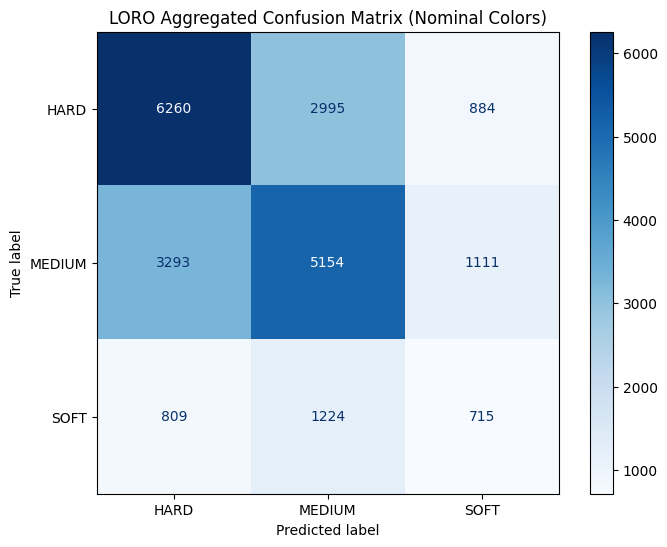


XGBOOST DECISION TREE:


c:\Users\c\Desktop\coding\ai_f1\.venv\Lib\site-packages\xgboost\plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


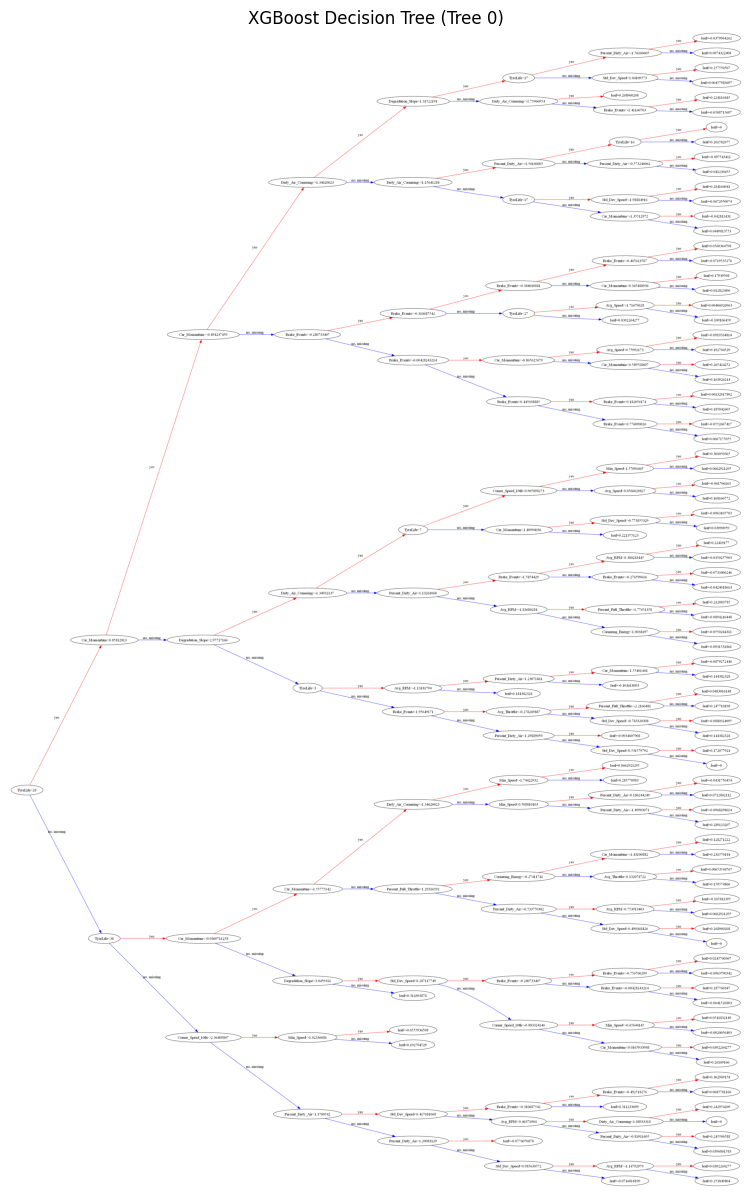


SHAP INTERPRETABILITY:


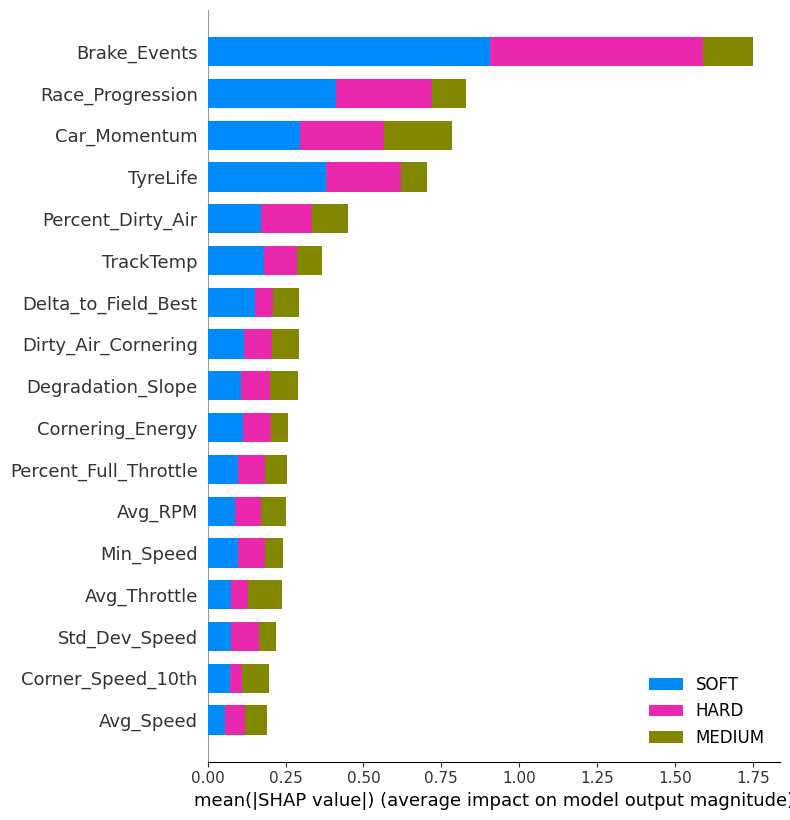

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import shap
import matplotlib.pyplot as plt

reverse_mapping = {0: 'HARD', 1: 'MEDIUM', 2: 'SOFT'}
target_names = [reverse_mapping[c] for c in final_model.classes_]

print("\nCLASSIFICATION REPORT:")
print(classification_report(
    all_y_true, 
    all_y_pred, 
    labels=final_model.classes_, 
    target_names=target_names, 
    zero_division=0
))

print("\nCONFUSION MATRIX:")
cm_strict = confusion_matrix(all_y_true, all_y_pred, labels=final_model.classes_)
disp_strict = ConfusionMatrixDisplay(confusion_matrix=cm_strict, display_labels=target_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp_strict.plot(cmap='Blues', ax=ax)
plt.title("LORO Aggregated Confusion Matrix (Nominal Colors)")
plt.show()

print("\nXGBOOST DECISION TREE:")
try:
    final_model.get_booster().feature_names = list(X.columns)
    fig, ax = plt.subplots(figsize=(30, 15)) 
    xgb.plot_tree(final_model, num_trees=0, ax=ax, rankdir='LR')
    plt.title("XGBoost Decision Tree (Tree 0)")
    plt.show()
except Exception as e:
    print(f"Could not plot tree (Graphviz likely missing on OS level). Error: {e}")

print("\nSHAP INTERPRETABILITY:")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

if len(np.array(shap_values).shape) == 3:
    shap_values_formatted = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    shap_values_formatted = shap_values

shap.summary_plot(
    shap_values_formatted, 
    X, 
    class_names=target_names, 
    plot_type="bar", 
    show=True
)

# EVALUATE ON AUSTRIA


 SPECIFIC RACE EVALUATION: 2025_Austria

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        HARD       0.85      0.88      0.86       417
      MEDIUM       0.90      0.85      0.87       539
        SOFT       0.76      1.00      0.86        54

    accuracy                           0.87      1010
   macro avg       0.84      0.91      0.87      1010
weighted avg       0.87      0.87      0.87      1010


CONFUSION MATRIX:


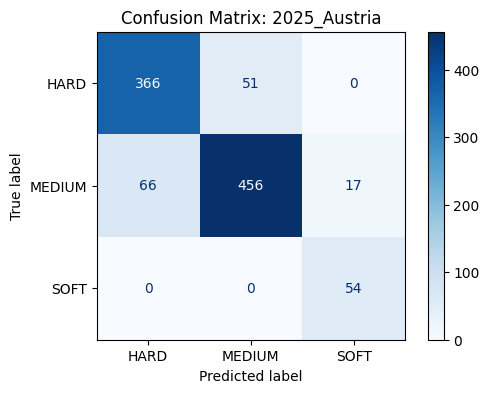


SHAP INTERPRETABILITY: 2025_Austria


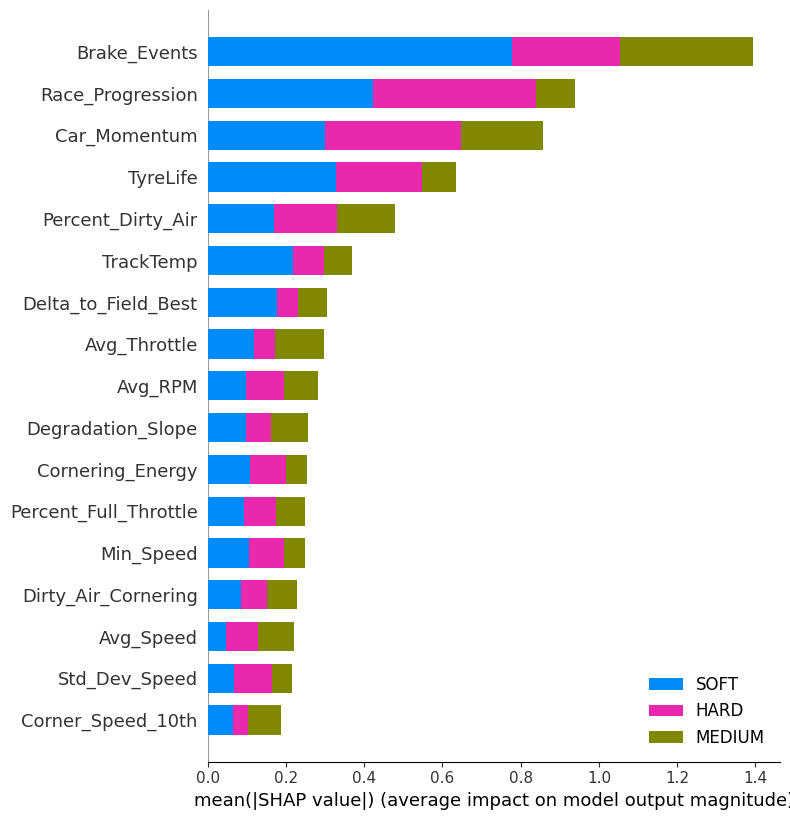

In [ ]:

all_race_labels = []
logo = LeaveOneGroupOut()
races_array = groups_race.values

for _, cv_val_idx in logo.split(X, y, groups=groups_race):
    held_out_race = races_array[cv_val_idx[0]]
    all_race_labels.extend([held_out_race] * len(cv_val_idx))

oof_df = pd.DataFrame({
    'Race_ID': all_race_labels,
    'True_Label': all_y_true,
    'Predicted_Label': all_y_pred
})

target_race = '2025_Austria' 

race_preds = oof_df[oof_df['Race_ID'] == target_race]

print("\nCLASSIFICATION REPORT:")
print(classification_report(
    race_preds['True_Label'], 
    race_preds['Predicted_Label'], 
    labels=final_model.classes_, 
    target_names=target_names, 
    zero_division=0
))

print("\nCONFUSION MATRIX:")
cm_race = confusion_matrix(race_preds['True_Label'], race_preds['Predicted_Label'], labels=final_model.classes_)
disp_race = ConfusionMatrixDisplay(confusion_matrix=cm_race, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 4))
disp_race.plot(cmap='Blues', ax=ax)
plt.title(f"Confusion Matrix: {target_race}")
plt.show()

print(f"\nSHAP INTERPRETABILITY: {target_race}")

X_race = master_df[master_df['Race_ID'] == target_race][features]

# use already-trained final_model
explainer = shap.TreeExplainer(final_model)
shap_values_race = explainer.shap_values(X_race)

if len(np.array(shap_values_race).shape) == 3:
    shap_values_race_formatted = [shap_values_race[:, :, i] for i in range(shap_values_race.shape[2])]
else:
    shap_values_race_formatted = shap_values_race

shap.summary_plot(
    shap_values_race_formatted, 
    X_race, 
    class_names=target_names, 
    plot_type="bar", 
    show=True
)

# EVALUATE ON BELGIUM


 SPECIFIC RACE EVALUATION: 2025_Belgium

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        HARD       0.12      0.96      0.21        52
      MEDIUM       0.98      0.21      0.34       485
        SOFT       0.00      0.00      0.00         0

    accuracy                           0.28       537
   macro avg       0.37      0.39      0.18       537
weighted avg       0.90      0.28      0.33       537


CONFUSION MATRIX:


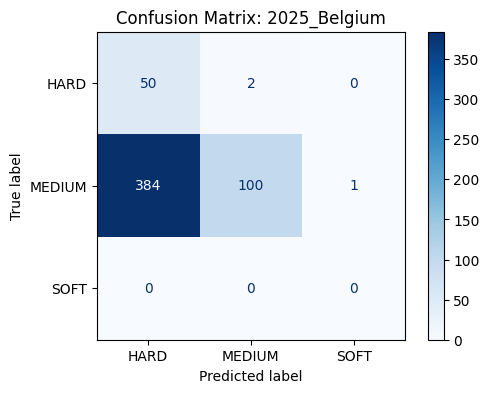


SHAP INTERPRETABILITY: 2025_Belgium


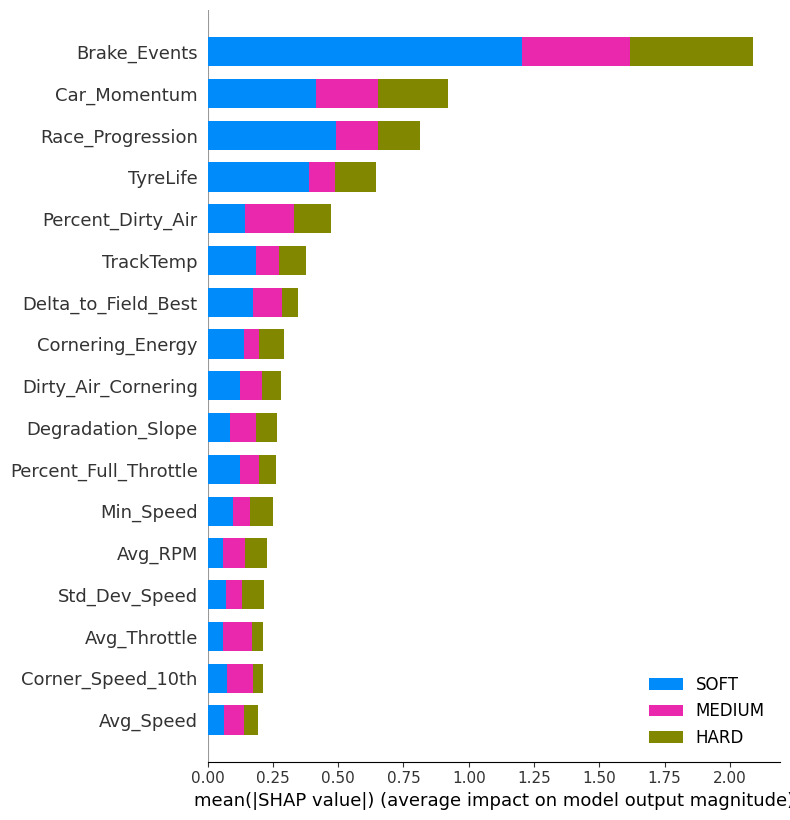

In [ ]:
all_race_labels = []
logo = LeaveOneGroupOut()
races_array = groups_race.values

for _, cv_val_idx in logo.split(X, y, groups=groups_race):
    held_out_race = races_array[cv_val_idx[0]]
    all_race_labels.extend([held_out_race] * len(cv_val_idx))

oof_df = pd.DataFrame({
    'Race_ID': all_race_labels,
    'True_Label': all_y_true,
    'Predicted_Label': all_y_pred
})

target_race = '2025_Belgium' 

race_preds = oof_df[oof_df['Race_ID'] == target_race]

print("\nCLASSIFICATION REPORT:")
print(classification_report(
    race_preds['True_Label'], 
    race_preds['Predicted_Label'], 
    labels=final_model.classes_, 
    target_names=target_names, 
    zero_division=0
))

print("\nCONFUSION MATRIX:")
cm_race = confusion_matrix(race_preds['True_Label'], race_preds['Predicted_Label'], labels=final_model.classes_)
disp_race = ConfusionMatrixDisplay(confusion_matrix=cm_race, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 4))
disp_race.plot(cmap='Blues', ax=ax)
plt.title(f"Confusion Matrix: {target_race}")
plt.show()


print(f"\nSHAP INTERPRETABILITY: {target_race}")

X_race = master_df[master_df['Race_ID'] == target_race][features]

explainer = shap.TreeExplainer(final_model)
shap_values_race = explainer.shap_values(X_race)

if len(np.array(shap_values_race).shape) == 3:
    shap_values_race_formatted = [shap_values_race[:, :, i] for i in range(shap_values_race.shape[2])]
else:
    shap_values_race_formatted = shap_values_race

shap.summary_plot(
    shap_values_race_formatted, 
    X_race, 
    class_names=target_names, 
    plot_type="bar", 
    show=True
)